### Predicting herat disease using machine learning

This notebook looks into using various Python-based machine learning and data science libraries in an attempt to build a machine learning model capable of predicting whether or not someone has heart disease based on their medical attributes.

We're going to take the following approach:
1. Problem definition
2. Data
3. Evaluation
4. Features
5. Modelling
6. Experimentation

## 1.Problem Definition

In a statement,
> Given clinical parameters about a patient, can we predict whether or not they have heart disease

## 2. Data

The original data came from the Cleaveland data from the UCI machine learning repository.
https://archive.ics.uci.edu./ml/datasets/heart+Disease

There is also a version of it available on Kaggle. https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

## 3. Evaluation

> If we can reach 95% accuracy at predicting whether or not a ptient has heart  disease during the proof of concept, we'll persue the project. 

## 4. Features

This is where you'll get different information about each of the features in your data.

**Create data dictionary**

* age
* sex
* chest pain type (4 values)
* resting blood pressure
* serum cholestoral in mg/dl
* fasting blood sugar > 120 mg/dl
* resting electrocardiographic results (values 0,1,2)
* maximum heart rate achieved
* exercise induced angina
* oldpeak = ST depression induced by exercise relative to rest
* the slope of the peak exercise ST segment
* number of major vessels (0-3) colored by flourosopy
* thal: 0 = normal; 1 = fixed defect; 2 = reversable defect
* The names and social security numbers of the patients were recently removed from the database, replaced with dummy values.

## Preparing the tools

We're going to use pandas, Matplotlib and NumPy for data analysis and manipulation

In [3]:
# Import all the tools we need

# Regular EDA (exploratory data analysis) and plotting libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from skimpy import skim
from summarytools import dfSummary

# we want our plots to appear inside the notebook
%matplotlib inline 

# Models from Scikit-Learn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Model evaluations
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, accuracy_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay

In [4]:
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 303    │ │ int64       │ 13    │                                                          │
│ │ Number of columns │ 14     │ │ float64     │ 1     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━━━┓  │
│ ┃ column       ┃ NA   ┃ NA %   ┃ mean      ┃ sd        ┃ p0    ┃ p25     ┃ p50   ┃ p75     ┃ p100  ┃ hist    ┃  │
│ ┡━━━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━━━┩  │
│ │ age          │    0 │      0 │     54.37 │     9.082 │    29 │    47.5 │    55 │      61 │    77 │ ▁▃▅▇▅▁  │  │
│ │ sex          │    0 │      0 │    0.6832 │     0.466 │     0 │       0 │     1 │       1 │     1 │ ▃    ▇  │  │
│ │ cp           │    0 │      0 │     0.967 │     1.032 │     0 │       0 │     1 │       2 │     3 │ ▇ ▃ ▅▁  │  │
│ │ trestbps     │    0 │      0 │     131.6 │     17.54 │    94 │     120 │   130 │     140 │   200 │  ▃▇▇▃▁  │  │
│ │ chol         │    0 │      0 │     246.3 │     51.83 │   126 │     211 │   240 │   274.5 │   564 │   ▂▇▃   │  │
│ │ fbs          │    0 │      0 │    0.1485 │    0.3562 │     0 │       0 │     0 │       0 │     1 │ ▇    ▁  │  │
│ │ restecg      │    0 │      0 │    0.5281 │    0.5259 │     0 │       0 │     1 │       1 │     2 │  ▇  ▇   │  │
│ │ thalach      │    0 │      0 │     149.6 │     22.91 │    71 │   133.5 │   153 │     166 │   202 │  ▂▃▇▇▁  │  │
│ │ exang        │    0 │      0 │    0.3267 │    0.4698 │     0 │       0 │     0 │       1 │     1 │ ▇    ▃  │  │
│ │ oldpeak      │    0 │      0 │      1.04 │     1.161 │     0 │       0 │   0.8 │     1.6 │   6.2 │  ▇▃▁▁   │  │
│ │ slope        │    0 │      0 │     1.399 │    0.6162 │     0 │       1 │     1 │       2 │     2 │ ▁  ▇ ▇  │  │
│ │ ca           │    0 │      0 │    0.7294 │     1.023 │     0 │       0 │     0 │       1 │     4 │  ▇▃ ▂▁  │  │
│ │ thal         │    0 │      0 │     2.314 │    0.6123 │     0 │       2 │     2 │       3 │     3 │   ▁ ▇▆  │  │
│ │ target       │    0 │      0 │    0.5446 │    0.4988 │     0 │       0 │     1 │       1 │     1 │ ▇    ▇  │  │
│ └──────────────┴──────┴────────┴───────────┴───────────┴───────┴─────────┴───────┴─────────┴───────┴─────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

In [5]:
dfSummary(df)

No,Variable,Stats / Values,Freqs / (% of Valid),Graph,Missing
1,age[int64],Mean (sd) : 54.4 (9.1)min < med < max:29.0 < 55.0 < 77.0IQR (CV) : 13.5 (6.0),41 distinct values,"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjEsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvc2/+5QAAAAlwSFlzAAAPYQAAD2EBqD+naQAAAnpJREFUeJzt3b2O2kAYRuGZwK68oIAQEXS+gUgpKGlyB7nYtOlSgLQ1d0CDEIgf4ayFMY6cKl0WmzHzTs7TbLNmXRyxg/F8tkVRGMB3Hx59AsB7tN/1W2iMtfbFGPNc4yXORVG8mcAQqmeRDofDb71eb1D1NY7H485a+z20WAnVL89lpNPp9K3f76e3Hnw4HKLZbDbYbrflOzKhwq0y0tFo9Kvi4S8mQITq1zqzd71enxyckjxC9WidmWVZlOf55zRNfxpjqr6jBolQPVpnLpfLwWKx6Fwul5a709NEqB6tM3e7XZDry3vggj8kECokECokECokECokECokECokECokECokECokECokECokECokcPdUYPI8L2+87llrg9oYSKgBSZLkKcuyL3Ect1qtVhrSxkBCDcj5fG5HUdSZTCbpeDzehbQxkFAD1O12q24O9PbGbT5MQQKhQkKw//oZjROWIEO9x2ic/X5/stb+MMbc+umZvfkOBBlq3dE4q9Xq43w+/xrH8adbL/OwN9+NUEOtNRqn3LZc9TIPe/PdCDrUR1zmYW/+fxgqM5zgfajMcIJEqMxwgkqofzDDCSW+mYIEQoUEQoUEQoUEQoUEQoUEQoUEQoUEQoUEQoUEQoUEQoUEQoUEQoUEQoUEQoUE72+cRnNqjqx0OrSDUHGXkZWux1YSKmqPrGxibGXb4/lPbHnWGllZcrZXre3r/Ce2PKOpd9Ra85/Y8oxG16h15j+5OSMo4joqJBAqJBAqJBAqJBAqJPDNFCQeb0mokHi85T9DZeozfHi8Zdv11OfNZvNqKjidTlH5M0mSaL1ed5o69pF/W/W8zV/Hu/IbQMF7TzJoSiEAAAAASUVORK5CYII="">",0(0.0%)
2,sex[int64],1. 12. 0,207 (68.3%)96 (31.7%),"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAJsAAAAuCAYAAAA/ZmtKAAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjEsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvc2/+5QAAAAlwSFlzAAAPYQAAD2EBqD+naQAAATpJREFUeJzt20tqw0AQRdHqIEwykTACLUaLyGKzCO1GGPUgDp60qXkwhMATVX3PIFM15Maf0K+01gxQKGb2YWYXydPwH4/W2t0CG+Z5/hzH8Xr2QfBarfVWSvmKHNzgoa3rep+m6efsw+B3x3G8b9t23ffd34HixuY/PLRlWb7PPgxe8o87ob2dfQD0g9ggQ2yQITbIEBtkiA0yxAYZYoMMsUGG2CBDbJAhNsgQG2SIDTLEBu19Nr+cp3sk/irL72fw68Z+CzTD5bzMaq033yFYYAxe4nhE3h+4wpQPKlle2cL/1fcgxZQvw8ytB+GnfFlmbj3IMuXjm3QA/FMXMsQGGWKDDLFBhtggQ2yQITbIEBtkiA0yxAYZYoMMsUGG2CBDbJAhNsiEn/JFPntvUkz5MszcesDgBabyBApbat+Ehi7+AAAAAElFTkSuQmCC"">",0(0.0%)
3,cp[int64],1. 02. 23. 14. 3,143 (47.2%)87 (28.7%)50 (16.5%)23 (7.6%),"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAJsAAABcCAYAAAB5jMeAAAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjEsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvc2/+5QAAAAlwSFlzAAAPYQAAD2EBqD+naQAAAdhJREFUeJzt20GKGlEARdGqICGZKI3gYlxEFptFuBsJOkiHTCrUAgKh7b76zTmDHmohl7JL/puXZZmg8Cl5FxAbpXmapq/TNH1O33U8v5dleb33RYxus9/vv22325d7X8gju16vP+Z5/i6422zW0I7H4+tut/t142s9pcvl8uV0Or2cz+f17i+2G2zWP2toh8Ph5y0v9OTWfzW4kQcEMmIjIzYyYiMjNjJiIyM2MmIjIzYyYiMjNjJiIyM22lMf6zGa7i3H4rN5P5v1YOB6Xssxmr9bP6P1tO69r2N0joX/G8fC38FsykfFAwKZUb9Gfa0NaMh1lbXTmIZbV1k7jWvUdZWfaQbkAYGM2MiIjYzYyIiNjNjIiI2M2MiIjYzYyIiNjNjIiI2M2MgMN+Ub6Vp5gimfad2YbBDImPLxlHc2d6P/XLausogiWVdZRFGvq4Z52uVj+FGXjNjIiI2M2MiIjYzYyIiNjNjIiI2M2MiIjYzYyIiNjNh4rnWVRRTpusoiChsEMtZVPPSdzR2KZl1lJUWyrrKSol5XWUnxJn7UJSM2MmIjIzYyYiMjNjJiIyM2MmIjIzYyYiMjNjJiIyM2HnNdZSVFuq6ykuKtbBDIWFeR8YDAVPkDJ5zYua0WnZcAAAAASUVORK5CYII="">",0(0.0%)
4,trestbps[int64],Mean (sd) : 131.6 (17.5)min < med < max:94.0 < 130.0 < 200.0IQR (CV) : 20.0 (7.5),49 distinct values,"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjEsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvc2/+5QAAAAlwSFlzAAAPYQAAD2EBqD+naQAAAplJREFUeJzt3LuO2kAUgOGZMJt4QeEiIujcUkRKQUmTN8jDpk23BfSIN6BBSIiL8OLYGEemSrFaLWbG+Iz+rx9w8Qsx9vHoPM8VUHefHn0BwEcY5Smt9bNS6vMdH5HkeX6yeEm4g/E10n6//6vdbvfKfsbhcNhqrX8Taz14GWrxS1pEOplMTp1OJ7518X6/D6bTaW+z2RS/yIRaA76GelVEOhgMXksuL/46oCbYTEEEQoUIhAoRjKe3mNqXy+XJwSXhQYyPt5jSNA2yLPsex/GLUqrsZgo1Yny8xbRcLnuLxaJ5Pp8b7i4PVapzqKVvMW23W24teYbNFEQgVIhAqBCBUCECoUKE2u/6HyXLsuKBQVtrXWY5s6yWEeoboih6StP0RxiGjUajcfOYILOs9hHqG5IkMUEQNMfjcTwcDre3rGWW1Q1CfUer1So7z8oDB8vYTEEEQoUIhAoRCBUiECpEIFSIQKgQgVAhAqFCBFPjg8p4kxTuQ733oDLeJEVVv6h3HVTGm6SodCil7EFlvEmK/7GZggiEChEIFSIQKkQgVIhAqBCBUCECoUIEQoUIhAoReK/fAY4Dso9QLeM4IDcI1TKOA3KDUB3hOCC72ExBBEKFCIQKEQgVIhAqRCBUiECoEIFQIQI3/P2aE/B2VoBQPZoT8HlWgFA9mRPwfVbAODzojEPOqp8T8HZWwLg66IxDzlDlL2rpg8445OwxMk+Hto2rg8445Kx6kcdD22ymPJJ4

In [2]:
df = pd.read_csv("dataset/heart-disease.csv")
df.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
df.shape # (rows, columns)

(303, 14)

## Data exploration (exploratory data analysis or EDA)

Goal is to become more about the data and become a subject matter expert on the data

1. What question(s) are you trying to solve?
2. What kind of data do we have and how do we treat different types?
3. What's missing from the data and how do you deal with it?
4. Where are the outliers and why should you care about them?
5. How can you add, change or remove features to get more out of your data?

In [4]:
df.head(), df.tail()

(   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
 0   63    1   3       145   233    1        0      150      0      2.3      0   
 1   37    1   2       130   250    0        1      187      0      3.5      0   
 2   41    0   1       130   204    0        0      172      0      1.4      2   
 3   56    1   1       120   236    0        1      178      0      0.8      2   
 4   57    0   0       120   354    0        1      163      1      0.6      2   
 
    ca  thal  target  
 0   0     1       1  
 1   0     2       1  
 2   0     2       1  
 3   0     2       1  
 4   0     2       1  ,
      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
 298   57    0   0       140   241    0        1      123      1      0.2   
 299   45    1   3       110   264    0        1      132      0      1.2   
 300   68    1   0       144   193    1        1      141      0      3.4   
 301   57    1   0       130   131    0        1      115  

In [5]:
df.target.value_counts()

target
1    165
0    138
Name: count, dtype: int64

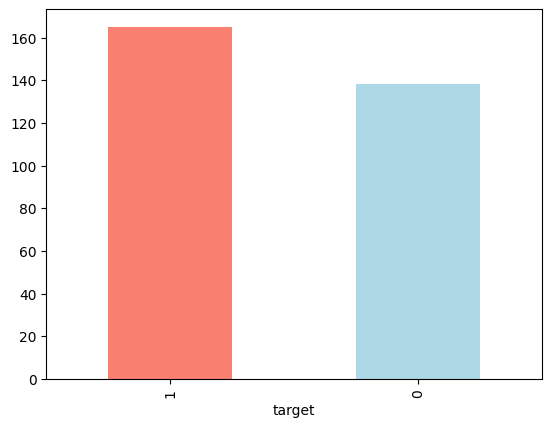

In [6]:
df["target"].value_counts().plot(kind="bar", color = ["salmon", "lightblue"]);

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [8]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [9]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### Heart Disease Frequency according to Sex

In [10]:
df.sex.value_counts()

sex
1    207
0     96
Name: count, dtype: int64

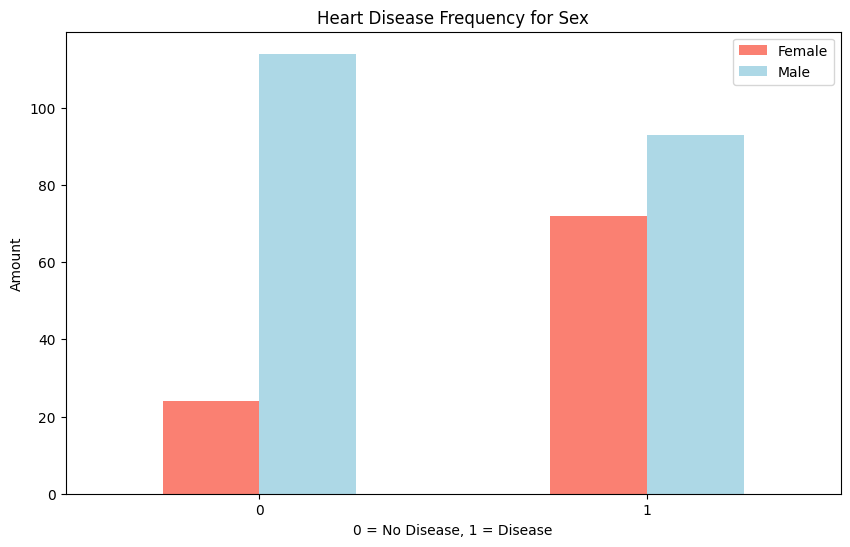

In [11]:
# Compare target column with sex column
pd.crosstab(df.target, df.sex).plot(kind = "bar",
                                   figsize = (10,6),
                                   color = ["salmon", "lightblue"])

plt.title("Heart Disease Frequency for Sex")
plt.xlabel("0 = No Disease, 1 = Disease")
plt.ylabel("Amount")
plt.legend(["Female", "Male"])
plt.xticks(rotation = 0); # the label below the graph

## Age vs Max Heart Rate for Heart Disease

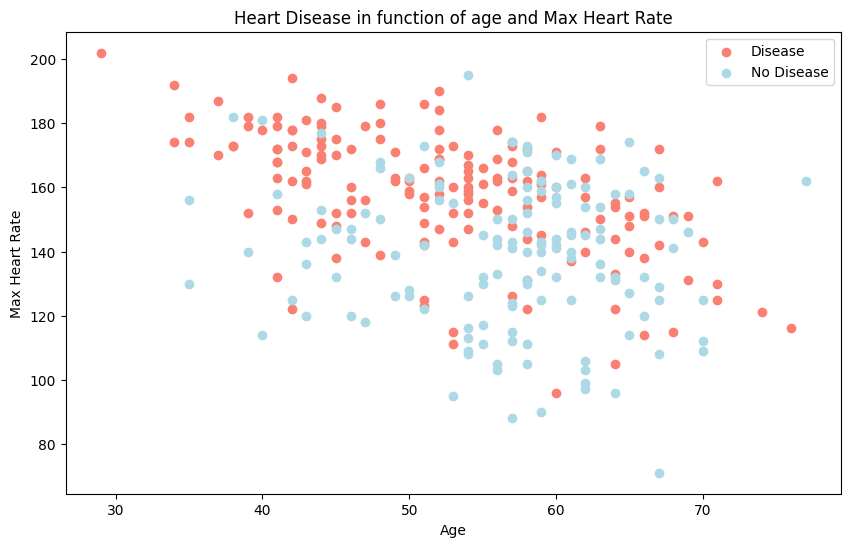

In [12]:
# Create another figure
plt.figure(figsize = (10,6))

# Scatter with positive examples
plt.scatter(df.age[df.target == 1],
           df.thalach[df.target == 1],
           c="salmon")


# Scatter with negative examples
plt.scatter(df.age[df.target == 0],
           df.thalach[df.target == 0],
           c = "lightblue")

# Add some helpful info
plt.title("Heart Disease in function of age and Max Heart Rate")
plt.xlabel("Age")
plt.ylabel("Max Heart Rate")
plt.legend(["Disease", "No Disease"])

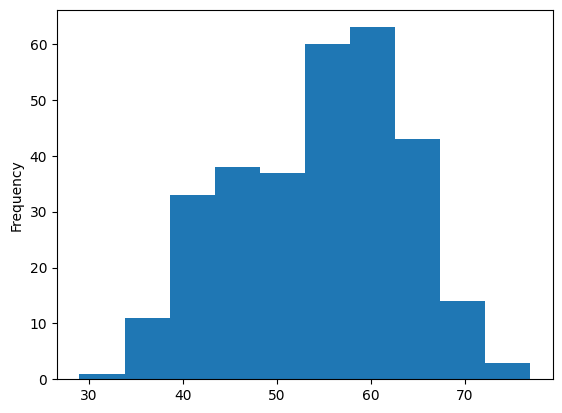

In [13]:
# Check the distribution of the age column with a histogram
df.age.plot.hist();

### Heart Disease Frequency per Chest Pain Type

chest pain type (4 values)

In [14]:
pd.crosstab(df.cp, df.target)

target,0,1
cp,,
0,104,39
1,9,41
2,18,69
3,7,16


(array([0, 1, 2, 3]),
 [Text(0, 0, '0'), Text(1, 0, '1'), Text(2, 0, '2'), Text(3, 0, '3')])

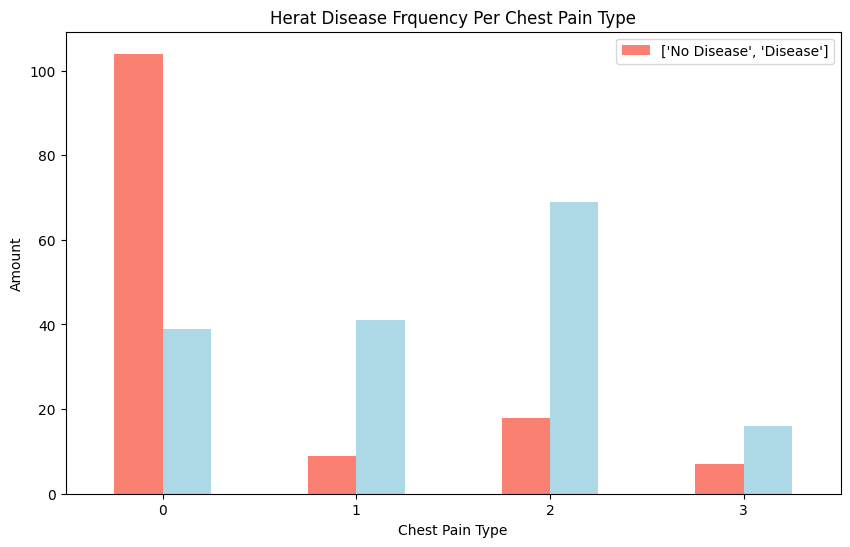

In [15]:
# Make the crosstab more visual

pd.crosstab(df.cp, df.target).plot(kind = "bar",
                                  figsize = (10,6),
                                  color = ["salmon", "lightblue"])


# Add some communication
plt.title("Herat Disease Frquency Per Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Amount")
plt.legend([["No Disease", "Disease"]])
plt.xticks(rotation = 0)

In [16]:
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


(14.5, -0.5)

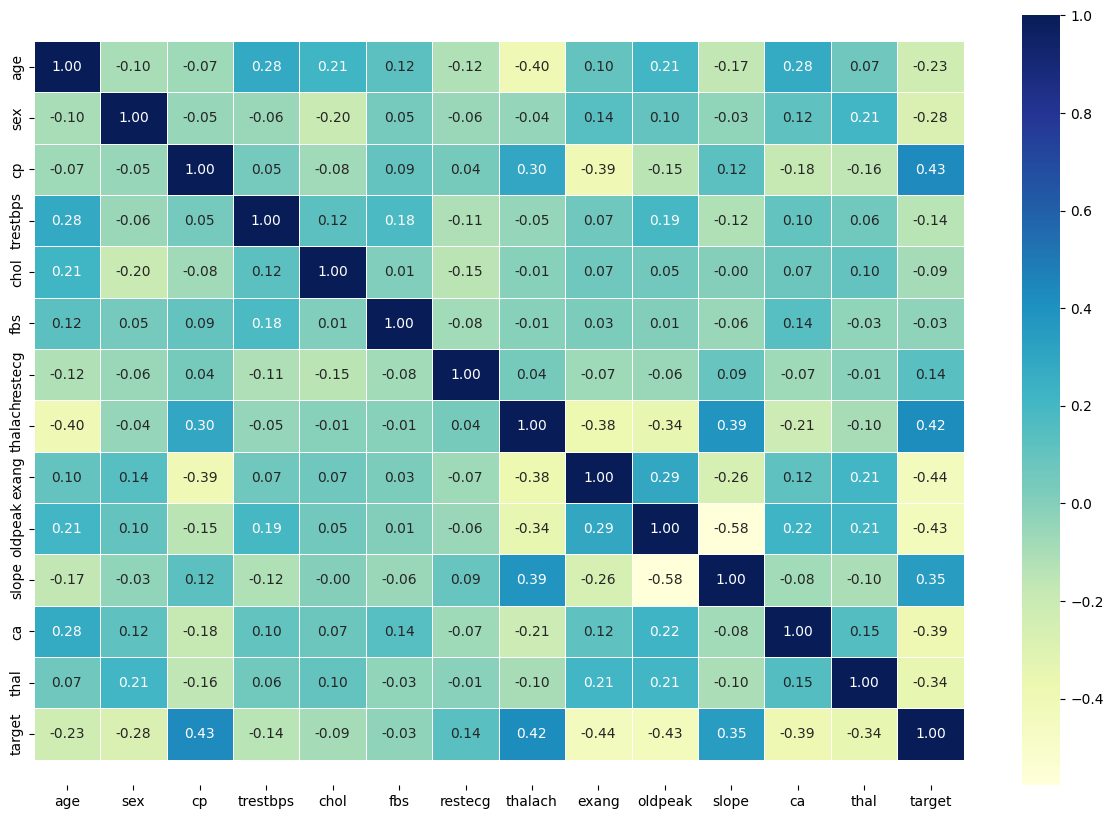

In [17]:
# Let's make our correlation matrix a little prettier

corr_matrix = df.corr()
fig, ax = plt.subplots(figsize = (15,10))
ax = sns.heatmap(corr_matrix, 
                annot = True,
                linewidths = 0.5,
                fmt = ".2f",
                cmap = "YlGnBu")

bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)

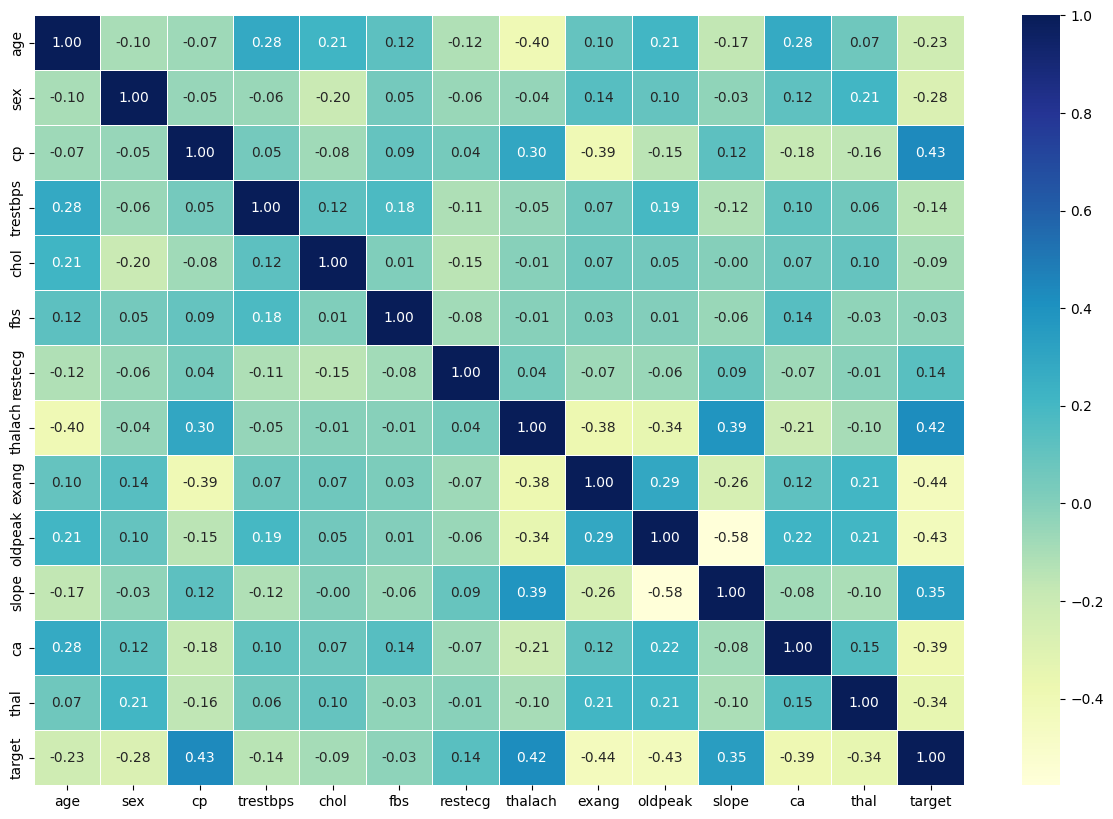

In [18]:
corr_matrix = df.corr()
fig, ax = plt.subplots(figsize = (15,10))
ax = sns.heatmap(corr_matrix, 
                annot = True,
                linewidths = 0.5,
                fmt = ".2f",
                cmap = "YlGnBu")

bottom, top = ax.get_ylim()

## 5. Modelling

In [19]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [20]:
X = df.drop(labels = "target", axis = 1)
y = df.target

In [21]:
# Split data into train and test sets
np.random.seed(42)

# Split the data into train and test set
X_train, X_test, y_train, y_test = train_test_split(X,
                                                   y,
                                                   test_size = 0.2)


In [22]:
len(X), len(y)

(303, 303)

In [23]:
y_train, len(y_train)

(132    1
 202    0
 196    0
 75     1
 176    0
       ..
 188    0
 71     1
 106    1
 270    0
 102    1
 Name: target, Length: 242, dtype: int64,
 242)

Now we've got our data split into training and test sets, it's time to build a machine learning model.

We'll train it (find the patterns) on the training set.

And we'll test it (use the patterns) on the test set.

1. LogisticRegression
2. KNearestNeighbour Classification
3. RandomForestClassifier



In [24]:
# Put models in a dictionary

models = {"Logistic Regression": LogisticRegression(),
         "KNN": KNeighborsClassifier(),
         "Random Forest": RandomForestClassifier()}

# Create a function to fit and score models

def fit_and_score(models, X_train, X_test, y_train, y_test):
    """
    Fits and evaluates given machine learning models.
    models :  a dict of different Scikit-Learn machine learning models
    X_train : trainign data (no labels)
    X_test : testing data (no labels)
    y_train : trainign data (no labels)
    y_test : test labels """
    
    # Set random seed
    np.random.seed(42)
    
    # Make a dictionary to keep model scores
    model_scores = {}
    
    # Loop through models
    
    for name, model in models.items():
        # Fir the model to the data
        model.fit(X_train, y_train)
        
        # Evaluate the model and append its score to model _scores
        model_scores[name] = model.score(X_test, y_test)
        
    return model_scores

In [25]:
model_scores = fit_and_score(models = models,
                            X_train = X_train,
                            X_test = X_test,
                            y_train = y_train,
                            y_test = y_test)

model_scores

c:\Users\hassa\File_Hub\Documents\Projects\Heart_Disease_Classification\heart-disease-classification\heart-disease-classification\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'Logistic Regression': 0.8852459016393442,
 'KNN': 0.6885245901639344,
 'Random Forest': 0.8360655737704918}

## Model Comparison

(array([0, 1, 2]),
 [Text(0, 0, 'Logistic Regression'),
  Text(1, 0, 'KNN'),
  Text(2, 0, 'Random Forest')])

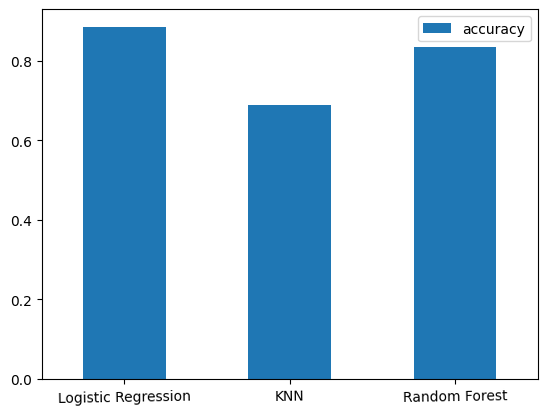

In [26]:
model_compare = pd.DataFrame(model_scores, index = ["accuracy"])
model_compare.T.plot.bar()
plt.xticks(rotation = 1)

Now we've got a baseline model.. and we know a model's first predictions aren't always what we should based our next steps off. What should we do?

Let's look at the following:
* Hyperparameter tuning
* Feature importance
* Confusion Matrix
* Cross validation
* Precision
* Recall
* F1 Score
* Classification report
* ROC Curve
* Area under the curve (AUC)

### Hypterparameter tuning

In [27]:
# Let's tune KNN

train_scores = []
test_scores = []

# Create of different values for n_neigbors
neighbors = range(1,21)

# Setup KNN instance
knn = KNeighborsClassifier()

# Loop through different n_neighbors
for i in neighbors:
    knn.set_params(n_neighbors=i)
    
    # Fit the algorithm
    knn.fit(X_train, y_train)
    
    # Update the training scores list
    train_scores.append(knn.score(X_train, y_train))
    
    # Update the test scores list
    test_scores.append(knn.score(X_test, y_test))

In [28]:
training_vs_test_knn = pd.DataFrame(data = [train_scores, test_scores], index = ["Train Scores", "Test Scores"])
training_vs_test_knn.T

,Train Scores,Test Scores
0,1.000000,0.622951
1,0.809917,0.639344
2,0.772727,0.655738
3,0.743802,0.672131
4,0.760331,0.688525
5,0.752066,0.721311
6,0.743802,0.704918
7,0.723140,0.688525
8,0.719008,0.688525
9,0.694215,0.704918


Maximum KNN score on the test data: 75.41%


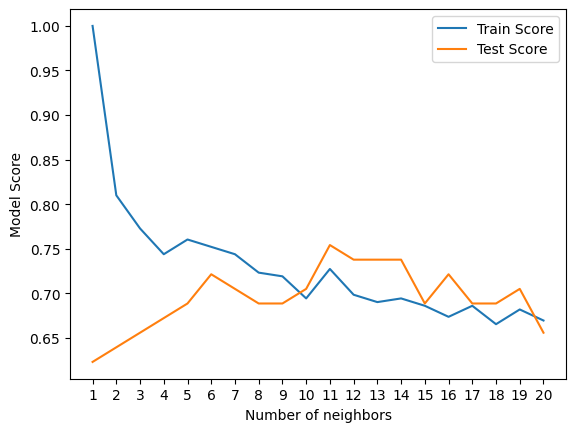

In [29]:
plt.plot(neighbors, train_scores, label = "Train Score")
plt.plot(neighbors, test_scores, label = "Test Score")
plt.xticks(np.arange(1,21,1))
plt.xlabel("Number of neighbors")
plt.ylabel("Model Score")
plt.legend()

print(f"Maximum KNN score on the test data: {max(test_scores) * 100:.2f}%")

## Hyperparameter tuning with RandomizedSearchCV

We're going to tune:
* LogisticRegression()
* RandomForestClassifier()
... using RandomizedSearchCV

In [30]:
np.logspace(-4, 4, 20)

array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04])

In [31]:
# Create a hyperparameter grid for LogisticRegression

log_reg_grid = {"C" : np.logspace(-4, 4, 20),
               "solver" : ["liblinear"]}

# Create a hyperparameter grid for RandomForestClassifier
rf_grid = {"n_estimators" : np.arange(10, 1000, 50),
          "max_depth": [None, 3, 5, 10],
          "min_samples_split": np.arange(2,20,2),
          "min_samples_leaf": np.arange(1,20,2)}

Now we've got hyperparameter grids setup for each of our models, let's tune them using RandomizedSearchCV...

In [32]:
# Tune LogisticRegression

np.random.seed(42)

# Setup random hyperparameter search for LogisticRegression
rs_log_reg = RandomizedSearchCV(LogisticRegression(),
                               param_distributions=log_reg_grid,
                                cv = 5,
                                n_iter = 20,
                               verbose = True) # Number of different combinations

# Fit random hyperparameter search model for Logistic Regression
rs_log_reg.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=LogisticRegression(), n_iter=20,
                   param_distributions={'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                                        'solver': ['liblinear']},
                   verbose=True)

In [33]:
rs_log_reg.best_params_

{'solver': 'liblinear', 'C': np.float64(0.23357214690901212)}

In [34]:
rs_log_reg.score(X_test, y_test)

0.8852459016393442

Now we've tuned LogisticRegression(), let's do the same for RandomForestClassifier()..

In [35]:
# Setup random seed
np.random.seed(42)

# Setup random hyperparameter search for RandomForestClassifier
rs_rf = RandomizedSearchCV(RandomForestClassifier(),
                          param_distributions = rf_grid,
                          cv = 5,
                          n_iter = 20,
                          verbose = True)

# Fit random hyperparameter search model for RandomForestClassiifer()
rs_rf.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_iter=20,
                   param_distributions={'max_depth': [None, 3, 5, 10],
                                        'min_samples_leaf': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19]),
                                        'min_samples_split': array([ 2,  4,  6,  8, 10, 12, 14, 16, 18]),
                                        'n_estimators': array([ 10,  60, 110, 160, 210, 260, 310, 360, 410, 460, 510, 560, 610,
       660, 710, 760, 810, 860, 910, 960])},
                   verbose=True)

In [36]:
# Find the best param from the hypertuned model

rs_rf.best_params_

{'n_estimators': np.int64(210),
 'min_samples_split': np.int64(4),
 'min_samples_leaf': np.int64(19),
 'max_depth': 3}

In [37]:
rs_rf.score(X_test,y_test), 

(0.8688524590163934,)

In [38]:
model_scores

{'Logistic Regression': 0.8852459016393442,
 'KNN': 0.6885245901639344,
 'Random Forest': 0.8360655737704918}

## Hyperparameters Tuning with GridSearchCV

Since our LogisticRegression model provides the best ascores so far, we'll try and improve them again using GridSearchCV

In [39]:
# Different hyperparameters for our Logistic Regression model
log_reg_grid = {"C": np.logspace(-4,4,30),
               "solver": ["liblinear"]}

# Setup grid hyperparameter search for Logistic Regression
gs_log_reg = GridSearchCV(LogisticRegression(),
                         param_grid = log_reg_grid,
                         cv = 5,
                         verbose = True)

gs_log_reg.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': array([1.00000000e-04, 1.88739182e-04, 3.56224789e-04, 6.72335754e-04,
       1.26896100e-03, 2.39502662e-03, 4.52035366e-03, 8.53167852e-03,
       1.61026203e-02, 3.03919538e-02, 5.73615251e-02, 1.08263673e-01,
       2.04335972e-01, 3.85662042e-01, 7.27895384e-01, 1.37382380e+00,
       2.59294380e+00, 4.89390092e+00, 9.23670857e+00, 1.74332882e+01,
       3.29034456e+01, 6.21016942e+01, 1.17210230e+02, 2.21221629e+02,
       4.17531894e+02, 7.88046282e+02, 1.48735211e+03, 2.80721620e+03,
       5.29831691e+03, 1.00000000e+04]),
                         'solver': ['liblinear']},
             verbose=True)

In [40]:
gs_log_reg.score(X_test, y_test)

0.8852459016393442

In [41]:
gs_log_reg.best_params_

{'C': np.float64(0.20433597178569418), 'solver': 'liblinear'}

# Evaluating our tuneed machine learning classifier, bbeyond accuracy

* ROC curve and AUC score
* Confusion matrix
* Classification report 
* Precision
* Recall
* F1-Score

.. and it would be geat if cross-validation was used where possible.

In [42]:
# Make predictions with tuned model

y_preds = gs_log_reg.predict(X_test)

In [43]:
y_preds

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

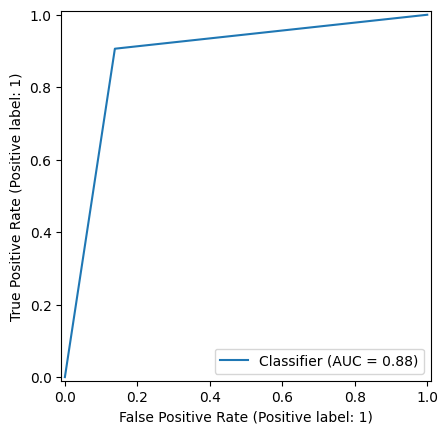

In [46]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_preds)

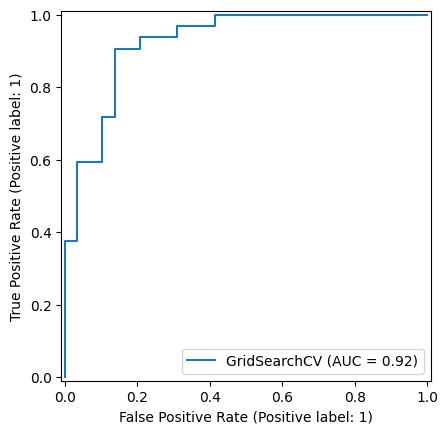

In [47]:
RocCurveDisplay.from_estimator(gs_log_reg, X_test, y_test)

In [48]:
# Confusion matrix
print(confusion_matrix(y_test, y_preds))

[[25  4]
 [ 3 29]]


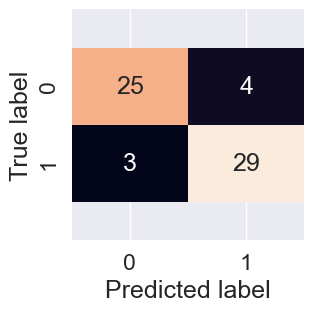

In [49]:
sns.set(font_scale = 1.5)

def plot_conf_mat(y_test, y_preds):
    """
    Plots a nice looking confusion matrix using Seaborn's heatmap()
    """
    
    fig, ax = plt.subplots(figsize = (3,3))
    ax = sns.heatmap(confusion_matrix(y_test, y_preds),
                    annot = True,
                    cbar = False)
    
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    
    bottom, top = ax.get_ylim()
    ax.set_ylim(bottom + 0.5, top - 0.5)
    
plot_conf_mat(y_test, y_preds)

In [50]:
import sklearn
sklearn.__version__

'1.6.1'

In [51]:
sklearn

<module 'sklearn' from 'c:\\Users\\hassa\\File_Hub\\Documents\\Projects\\Heart_Disease_Classification\\heart-disease-classification\\heart-disease-classification\\lib\\site-packages\\sklearn\\__init__.py'>

Now we've got a ROC curve, an AUC metric and a confusion matrix, let's get a classification report as well as cross-validated precision, recall and f1 score.

In [52]:
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



### Calculate evaluation metrics using cross-validation

We're going to calculate precision, recall and f1-score of our model using cross-validation and to do so we'll be using `cross_val_score()`

In [53]:
# Check the best hyperparameters
gs_log_reg.best_params_

{'C': np.float64(0.20433597178569418), 'solver': 'liblinear'}

In [54]:
# Create a new classifier with best parameters
clf = LogisticRegression(C = 0.20433597178569418,
                        solver = "liblinear")

In [55]:
# Cross validated accuracy

cv_acc = cross_val_score(clf,
                        X,
                        y,
                        cv = 5,
                        scoring = "accuracy")
cv_acc = cv_acc.mean()
cv_acc

np.float64(0.8479781420765027)

In [56]:
# Cross validated precision

cv_precision = cross_val_score(clf,
                              X,
                              y,
                              cv = 5,
                              scoring = "precision")

cv_precision = cv_precision.mean()
cv_precision

np.float64(0.8215873015873015)

In [57]:
# Cross Recall-Score

cv_recall = cross_val_score(clf,
                           X,
                           y,
                           cv = 5,
                           scoring = "recall")

cv_recall = cv_recall.mean()
cv_recall

np.float64(0.9272727272727274)

In [58]:
# Cross validated f1-score

cv_f1_score = cross_val_score(clf,
                             X,
                             y,
                             cv = 5,
                             scoring = "f1")

cv_f1_score = cv_f1_score.mean()
cv_f1_score

np.float64(0.8705403543192143)

In [59]:
# Visualize cross-validated metrics

cv_metrics = pd.DataFrame(data = {"Accuracy": cv_acc, "Precision": cv_precision, "Recall": cv_recall, "F1-Score": cv_f1_score}, index = [0])

(array([0, 1, 2, 3]),
 [Text(0, 0, 'Accuracy'),
  Text(1, 0, 'Precision'),
  Text(2, 0, 'Recall'),
  Text(3, 0, 'F1-Score')])

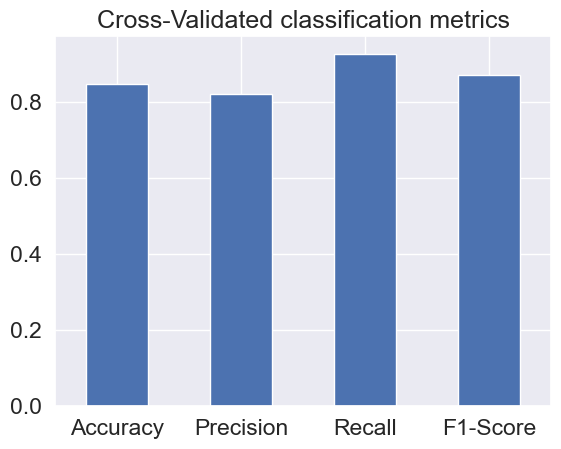

In [60]:
cv_metrics.T.plot.bar(title = "Cross-Validated classification metrics",
                     legend = False)

plt.xticks(rotation = 0)

In [61]:
cv_metrics.T.plot

### Feature Importance

Feature importance is another way of asking, "which features contributed most to the outcomes of the model and how did they contribute?"

Finding feature importance differs for Machine Learning model. One way is to search on how to find it

Let's find the feature importance for our LogisticRegressionModel...



In [62]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [63]:
# Fit an instance of LogisticRegression

gs_log_reg.best_params_

clf = LogisticRegression(C = 0.20433597178569418,
                        solver = "liblinear")

clf.fit(X_train, y_train)

LogisticRegression(C=0.20433597178569418, solver='liblinear')

In [64]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [65]:
# Check coef_

clf.coef_

array([[ 0.00320769, -0.86062047,  0.66001431, -0.01155971, -0.00166496,
         0.04017239,  0.31603402,  0.02458922, -0.6047017 , -0.56795457,
         0.45085391, -0.63733326, -0.6755509 ]])

In [66]:
# Match the coef's of features to columns
feature_dict = dict(zip(df.columns, list(clf.coef_[0])))
feature_dict

{'age': np.float64(0.0032076873709286024),
 'sex': np.float64(-0.8606204735539111),
 'cp': np.float64(0.6600143086174385),
 'trestbps': np.float64(-0.01155970641957489),
 'chol': np.float64(-0.0016649609500147373),
 'fbs': np.float64(0.04017238940156104),
 'restecg': np.float64(0.3160340177157746),
 'thalach': np.float64(0.02458922261936637),
 'exang': np.float64(-0.6047017032281077),
 'oldpeak': np.float64(-0.567954572983317),
 'slope': np.float64(0.4508539117301764),
 'ca': np.float64(-0.6373332602422034),
 'thal': np.float64(-0.6755508982355707)}

<Axes: title={'center': 'Feature Importance'}>

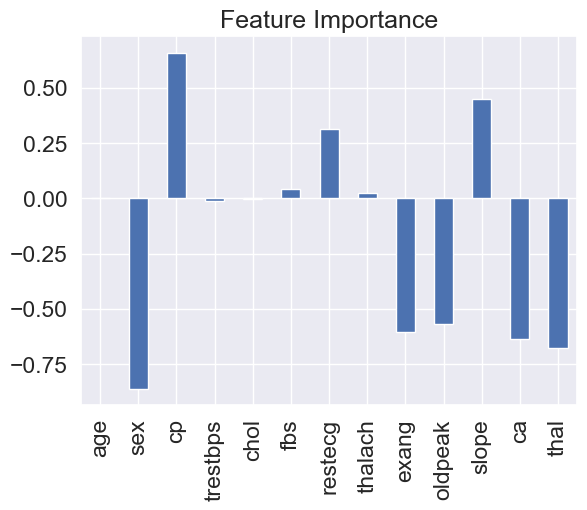

In [67]:
# Visualize feature importance

feature_df = pd.DataFrame(feature_dict, index=[0])
feature_df.T.plot.bar(title = "Feature Importance", legend = False)
# plt.xticks(rotation = 0)

### 6. Experimentation

If you haven't hit your evaluation metric yet... ask yourself...

* Could you collect mode data?
* Could you try a better model? Likewise CatBoost Or XGBoost?
* Could you improve the current models? (Beyond what we've done so far)
* If your model is good enough (you have hit your evaluation metric) how would you share it with others?

In [68]:
print([1,2,3,4,5,6] [-1: -5])

[]
